# JobAnalysis

In [ ]:
from scm.plams.tools.job_analysis import JobsAnalysis

In [2]:
from scm.plams.examples.JobAnalysis.run_jobs import folder_with_many_go_jobs
from scm.plams import AMSJob

folder = folder_with_many_go_jobs()
folder.absolute()

PosixPath('/home/benedini/branches_ams/scripting/scm/plams/examples/AdvancedSettings/data_go_many-TEST')

## Load Jobs

In [3]:
ja = JobsAnalysis.load_paths_of_inputs(folder)
ja.view_table()

paths                    
-------------------------
data_go_many-TEST/CCO.002
data_go_many-TEST/O.002  
data_go_many-TEST/N      
data_go_many-TEST/CCC    
data_go_many-TEST/CCO    
data_go_many-TEST/N.002  
data_go_many-TEST/O      
data_go_many-TEST/CCC.002


In [4]:
ja.load_jobs(job_loader=AMSJob.load_external)

In [5]:
ja.view_table(max_col_length=-1)

paths                     | jobs                                                                | names  
--------------------------+---------------------------------------------------------------------+--------
data_go_many-TEST/CCO.002 | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2638274f0> | CCO.002
data_go_many-TEST/O.002   | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc263827b20> | O.002  
data_go_many-TEST/N       | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2637f6700> | N      
data_go_many-TEST/CCC     | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2637f6fd0> | CCC    
data_go_many-TEST/CCO     | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2637aeeb0> | CCO    
data_go_many-TEST/N.002   | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc263761bb0> | N.002  
data_go_many-TEST/O       | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc263761790> | O      
data_go_many-TEST/CCC.002 | <scm.plams.interfa

## Settings Analysis

In [6]:
ja.get_nested_settings("input.ams.Task", default_type=str)

'input.ams.Task'

In [7]:
ja.view_table(max_col_length=20)

paths                   | jobs                    | names   | input.ams.Task      
------------------------+-------------------------+---------+---------------------
data_go_many-TEST/CC... | <scm.plams.interface... | CCO.002 | MolecularDynamics   
data_go_many-TEST/O.... | <scm.plams.interface... | O.002   | MolecularDynamics   
data_go_many-TEST/N     | <scm.plams.interface... | N       | GeometryOptimization
data_go_many-TEST/CC... | <scm.plams.interface... | CCC     | GeometryOptimization
data_go_many-TEST/CC... | <scm.plams.interface... | CCO     | GeometryOptimization
data_go_many-TEST/N.... | <scm.plams.interface... | N.002   | MolecularDynamics   
data_go_many-TEST/O     | <scm.plams.interface... | O       | GeometryOptimization
data_go_many-TEST/CC... | <scm.plams.interface... | CCC.002 | MolecularDynamics   


In [8]:
cols_added = ja.compare_settings(analyze_blocks=False, analyze_keys=True, none_is_unimportant=True)
ja.settings_cols

SettingsCols(['input.ams.GeometryOptimization.MaxIterations',
	 'input.ams.MolecularDynamics.NSteps',
	 'input.ams.Task'])

In [9]:
ja.settings_cols.rename(
    {
        k: k.replace("input.ams.", "").replace("MolecularDynamics", "MD").replace("GeometryOptimization", "GO")
        for k in ja.settings_cols.values
    }
)

In [10]:
ja.settings_cols

SettingsCols(['GO.MaxIterations',
	 'MD.NSteps',
	 'Task'])

In [11]:
ja.view_table(max_col_length=20)

paths                   | jobs                    | names   | GO.MaxIterations | Task                 | MD.NSteps
------------------------+-------------------------+---------+------------------+----------------------+----------
data_go_many-TEST/CC... | <scm.plams.interface... | CCO.002 | None             | MolecularDynamics    | 30       
data_go_many-TEST/O.... | <scm.plams.interface... | O.002   | None             | MolecularDynamics    | 30       
data_go_many-TEST/N     | <scm.plams.interface... | N       | 100              | GeometryOptimization | None     
data_go_many-TEST/CC... | <scm.plams.interface... | CCC     | 200              | GeometryOptimization | None     
data_go_many-TEST/CC... | <scm.plams.interface... | CCO     | 200              | GeometryOptimization | None     
data_go_many-TEST/N.... | <scm.plams.interface... | N.002   | None             | MolecularDynamics    | 20       
data_go_many-TEST/O     | <scm.plams.interface... | O       | 200              | Geometr

In [12]:
go_jobs = [i for i, row in enumerate(ja) if row.get("Task") == "GeometryOptimization"]
ja.view_table(indexes=go_jobs, max_col_length=20)
ref_go_job = go_jobs.pop(1)

paths                   | jobs                    | names | GO.MaxIterations | Task                 | MD.NSteps
------------------------+-------------------------+-------+------------------+----------------------+----------
data_go_many-TEST/N     | <scm.plams.interface... | N     | 100              | GeometryOptimization | None     
data_go_many-TEST/CC... | <scm.plams.interface... | CCC   | 200              | GeometryOptimization | None     
data_go_many-TEST/CC... | <scm.plams.interface... | CCO   | 200              | GeometryOptimization | None     
data_go_many-TEST/O     | <scm.plams.interface... | O     | 200              | GeometryOptimization | None     


In [13]:
ja.view_table(indexes=[ref_go_job], max_col_length=20)

paths                   | jobs                    | names | GO.MaxIterations | Task                 | MD.NSteps
------------------------+-------------------------+-------+------------------+----------------------+----------
data_go_many-TEST/CC... | <scm.plams.interface... | CCC   | 200              | GeometryOptimization | None     


## Errors and Timings

In [14]:
ja.get_job_info()

['ok', 'check', 'error']

In [15]:
ja.get_timings()

['CPUTime', 'SysTime', 'ElapsedTime']

In [16]:
ja.view_table(max_col_length=25)

paths                     | jobs                         | names   | GO.MaxIterations | Task                 | MD.NSteps | ok   | check | error | CPUTime  | SysTime  | ElapsedTime        
--------------------------+------------------------------+---------+------------------+----------------------+-----------+------+-------+-------+----------+----------+--------------------
data_go_many-TEST/CCO.002 | <scm.plams.interfaces.adf... | CCO.002 | None             | MolecularDynamics    | 30        | True | True  | None  | 0.12265  | 0.00792  | 0.13933801651000977
data_go_many-TEST/O.002   | <scm.plams.interfaces.adf... | O.002   | None             | MolecularDynamics    | 30        | True | True  | None  | 0.117186 | 0.012555 | 0.14169621467590332
data_go_many-TEST/N       | <scm.plams.interfaces.adf... | N       | 100              | GeometryOptimization | None      | True | True  | None  | 0.140021 | 0.01549  | 0.16779708862304688
data_go_many-TEST/CCC     | <scm.plams.interfaces.adf... | C

## Compare JobsResults 

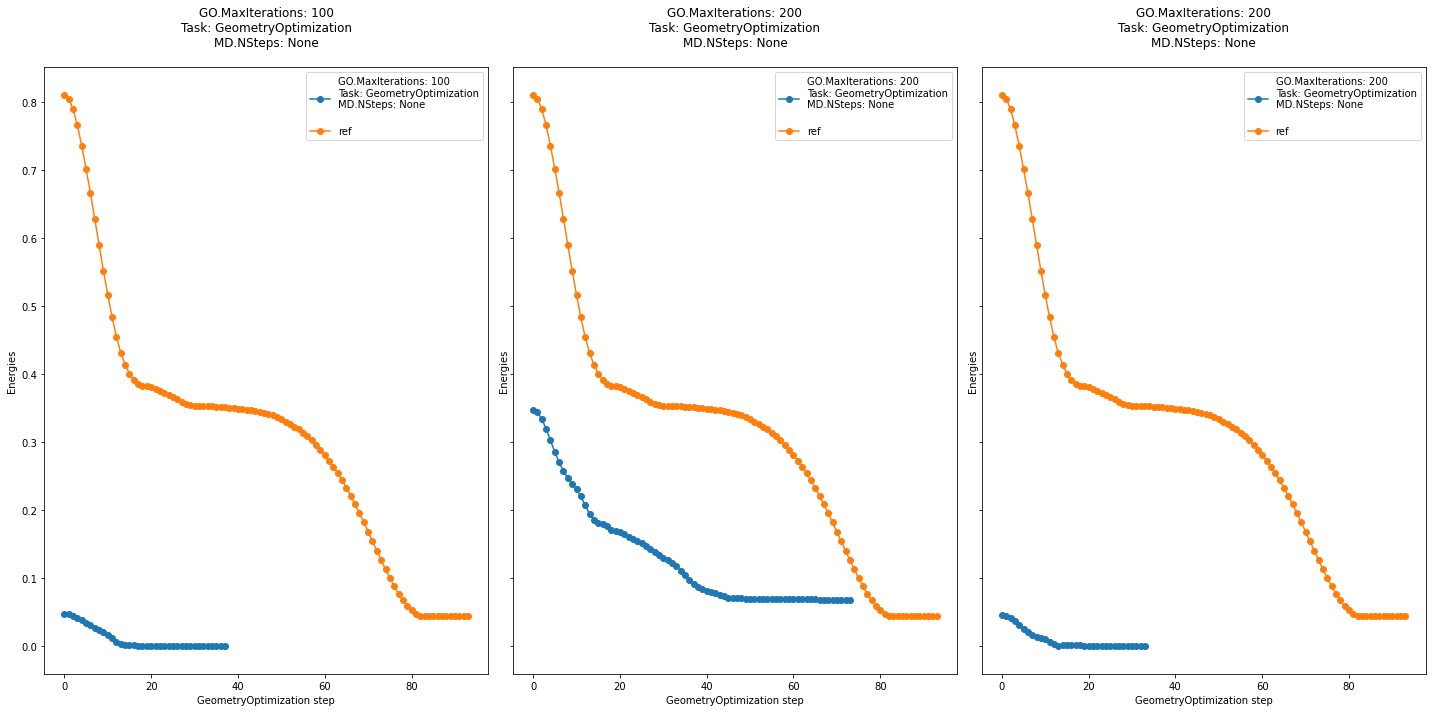

In [17]:
from scm.plams.tools.plot import plot_traj_en_forces


def plot_compared_mols(j, ax):
    plot_traj_en_forces(j, energy=True, forces=False, ax=ax, color_energy=None, color_forces=None)


fig = ja.success_checker_plotter(
    ref_job_idx=ref_go_job,
    indexes_to_check=go_jobs,
    success_plot=plot_compared_mols,
    separate_plot=True,
    ncols=3,
    figsize=(20, 10),
)

In [18]:
md_jobs = [i for i, row in enumerate(ja) if row.get("Task") != "GeometryOptimization"]
ja.view_table(indexes=go_jobs, max_col_length=40)
ref_md_job = md_jobs.pop(1)

paths                 | jobs                                        | names | GO.MaxIterations | Task                 | MD.NSteps | ok   | check | error | CPUTime  | SysTime  | ElapsedTime        
----------------------+---------------------------------------------+-------+------------------+----------------------+-----------+------+-------+-------+----------+----------+--------------------
data_go_many-TEST/N   | <scm.plams.interfaces.adfsuite.ams.AMSJo... | N     | 100              | GeometryOptimization | None      | True | True  | None  | 0.140021 | 0.01549  | 0.16779708862304688
data_go_many-TEST/CCO | <scm.plams.interfaces.adfsuite.ams.AMSJo... | CCO   | 200              | GeometryOptimization | None      | True | True  | None  | 0.139873 | 0.016614 | 0.18443012237548828
data_go_many-TEST/O   | <scm.plams.interfaces.adfsuite.ams.AMSJo... | O     | 200              | GeometryOptimization | None      | True | True  | None  | 0.126788 | 0.028013 | 0.15420198440551758


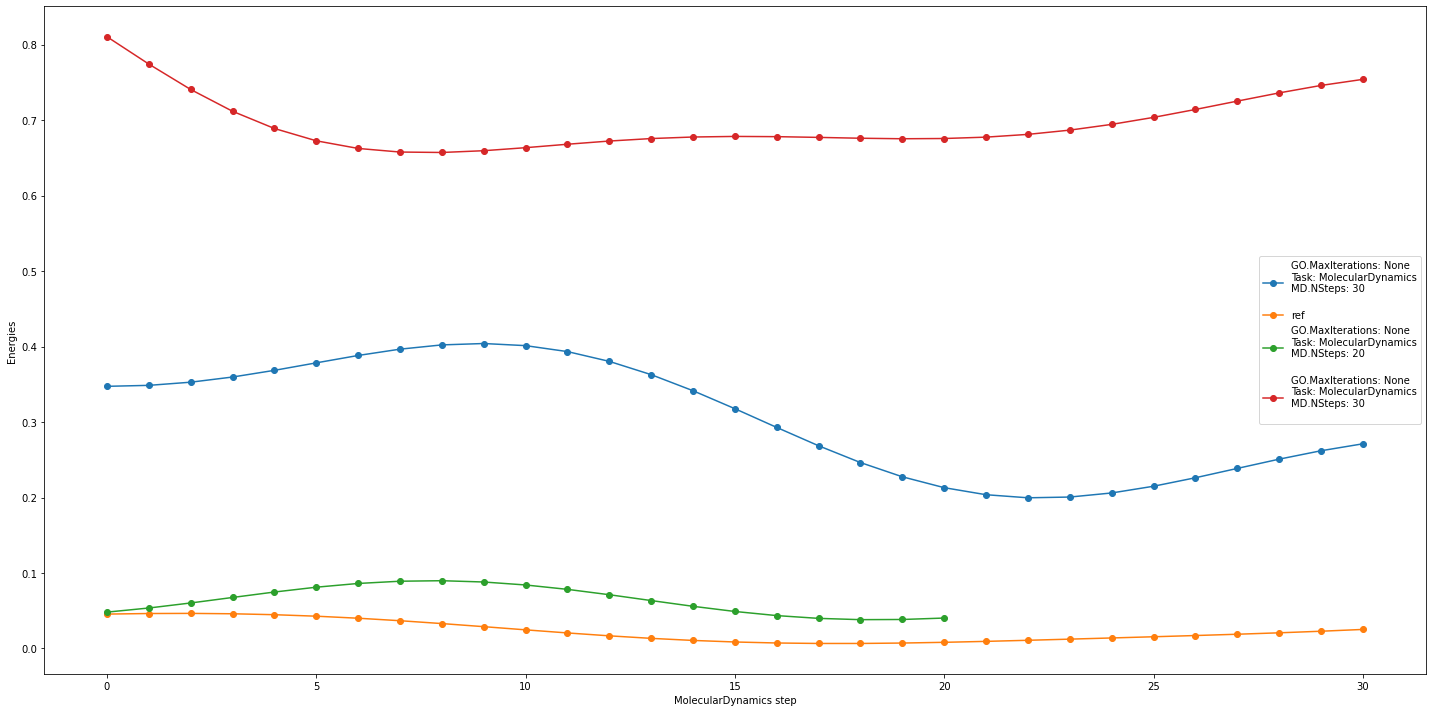

In [19]:
fig = ja.success_checker_plotter(
    ref_job_idx=ref_md_job,
    indexes_to_check=md_jobs,
    success_plot=plot_compared_mols,
    separate_plot=False,
    ncols=3,
    figsize=(20, 10),
)

## IO support for csv

In [20]:
from pathlib import Path

path_csv = Path("data.csv")
ja.to_csv(path_csv)

Data saved to data.csv


In [21]:
ja_2 = JobsAnalysis.from_csv("data.csv")
ja_2.load_jobs(AMSJob.load_external)

In [22]:
ja_2.view_table()

paths                     | names   | GO.MaxIterations | Task                 | MD.NSteps | ok   | check | error | CPUTime  | SysTime  | ElapsedTime         | jobs                                                               
--------------------------+---------+------------------+----------------------+-----------+------+-------+-------+----------+----------+---------------------+--------------------------------------------------------------------
data_go_many-TEST/CCO.002 | CCO.002 | None             | MolecularDynamics    | 30        | True | True  | None  | 0.12265  | 0.00792  | 0.13933801651000977 | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2631dc250>
data_go_many-TEST/O.002   | O.002   | None             | MolecularDynamics    | 30        | True | True  | None  | 0.117186 | 0.012555 | 0.14169621467590332 | <scm.plams.interfaces.adfsuite.ams.AMSJob object at 0x7fc2632546a0>
data_go_many-TEST/N       | N       | 100              | GeometryOptimization | None      | 

### Cleanup

In [25]:
import shutil

path_csv.unlink(missing_ok=True)
shutil.rmtree(folder)